In [2]:
import os

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../reports", exist_ok=True)
os.makedirs("../scripts", exist_ok=True)

print("Folders created")

Folders created


In [4]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../database/mutual_fund.db")

nav_df = pd.read_sql("""
SELECT amfi_code, date, nav
FROM fact_nav
""", conn)

nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
          .pct_change()
)

nav_df.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)

nav_df.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [5]:
returns = pd.read_csv("../data/processed/returns_computed.csv")
returns.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [6]:
returns = pd.read_csv("../data/processed/returns_computed.csv")

returns.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [7]:
import numpy as np

var_list = []

for fund, grp in returns.groupby("amfi_code"):
    ret = grp["daily_return"].dropna()

    var_95 = np.percentile(ret, 5)
    cvar = ret[ret <= var_95].mean()

    var_list.append([fund, var_95, cvar])

var_df = pd.DataFrame(
    var_list,
    columns=["amfi_code", "VaR_95", "CVaR"]
)

var_df.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

var_df.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [16]:
import sqlite3

conn = sqlite3.connect("../database/mutual_fund.db")

txn = pd.read_sql("""
SELECT * FROM fact_transactions
""", conn)

txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])

txn["cohort_year"] = (
    txn.groupby("investor_id")["transaction_date"]
       .transform("min")
       .dt.year
)

cohort = txn.groupby("cohort_year").agg({
    "amount_inr": ["mean", "sum"]
})

cohort.to_csv("../data/processed/cohort_analysis.csv")

cohort

amount_inr            
                      mean         sum
cohort_year                           
2024         107422.541832  3491125187
2025         109158.577061    30455243

In [17]:
txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"]
)

txn["cohort_year"] = (
    txn.groupby("investor_id")
       ["transaction_date"]
       .transform("min")
       .dt.year
)

cohort = txn.groupby("cohort_year").agg({
    "amount_inr": ["mean", "sum"]
})

cohort.to_csv(
    "../data/processed/cohort_analysis.csv"
)

cohort

amount_inr            
                      mean         sum
cohort_year                           
2024         107422.541832  3491125187
2025         109158.577061    30455243

In [18]:
import numpy as np

sip_txn = txn[
    txn["transaction_type"]=="SIP"
].copy()

sip_txn = sip_txn.sort_values(
    ["investor_id","transaction_date"]
)

sip_txn["gap_days"] = (
    sip_txn.groupby("investor_id")
           ["transaction_date"]
           .diff()
           .dt.days
)

risk_flags = (
    sip_txn.groupby("investor_id")
           ["gap_days"]
           .mean()
           .reset_index()
)

risk_flags["status"] = np.where(
    risk_flags["gap_days"] > 35,
    "At-Risk",
    "Healthy"
)

risk_flags.to_csv(
    "../data/processed/sip_risk_flags.csv",
    index=False
)

risk_flags.head()

,investor_id,gap_days,status
0,INV000001,76.0,At-Risk
1,INV000002,207.0,At-Risk
2,INV000003,238.0,At-Risk
3,INV000004,85.4,At-Risk
4,INV000005,14.0,Healthy


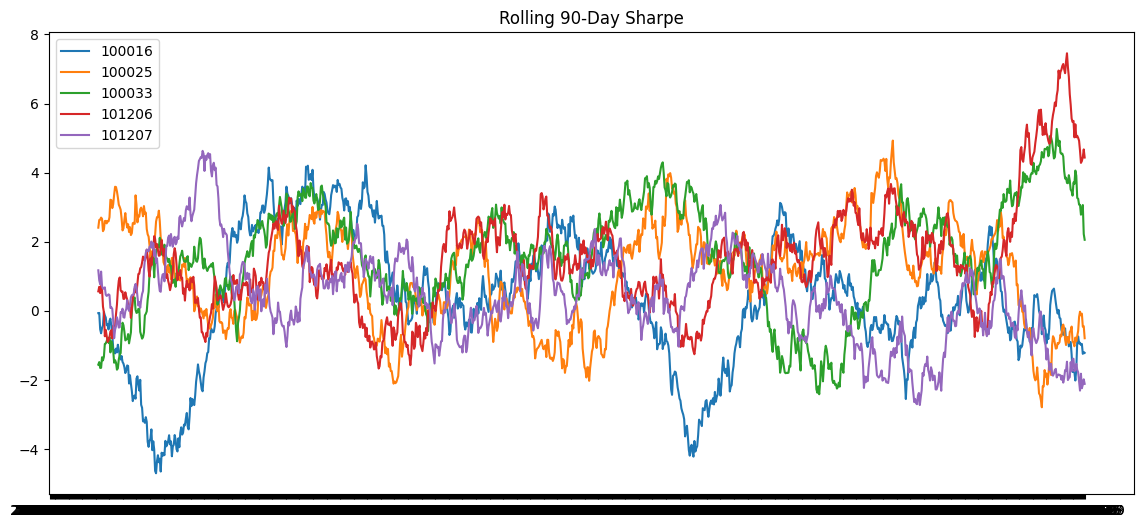

In [19]:
import matplotlib.pyplot as plt

top5 = returns["amfi_code"].unique()[:5]

plt.figure(figsize=(14,6))

for fund in top5:

    temp = returns[
        returns["amfi_code"] == fund
    ].copy()

    temp["rolling_sharpe"] = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe")

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()